# <img src="https://upload.wikimedia.org/wikipedia/commons/c/c3/Python-logo-notext.svg" width="35" alt="Python Logo"> Stack de Dados Módulo 3: Agrupamento e Cruzamento de Informações

Nesta etapa vamos transformar a nossa base limpa em conhecimento real. No módulo anterior nós garantimos que os dados estivessem consistentes e livres de erros. Agora chegou o momento em que os dados começam a contar a história do projeto. O analista deixa de olhar para linhas isoladas e passa a criar resumos inteligentes e métricas que apoiam a tomada de decisão. Essa é a fase onde extraímos o verdadeiro valor das informações usando o Pandas.

### O que vamos estruturar agora?
Vamos dominar quatro pilares fundamentais para gerar estatísticas da nossa base.
* **Agrupamento de Dados (GroupBy):** Como unir categorias iguais para extrair métricas e estatísticas específicas.
* **Tabelas Dinâmicas (Pivot Tables):** Como cruzar duas ou mais variáveis simultaneamente de forma semelhante ao que fazemos em planilhas tradicionais.
* **Junção de Tabelas (Merge):** Como conectar arquivos diferentes usando uma chave em comum para enriquecer a nossa análise.
* **Primeiras Visualizações (Plotagem Básica):** Como gerar os primeiros gráficos diretamente pelo código para ilustrar as nossas descobertas.

## 🗂️ Conhecendo nosso Dataset

Neste módulo, vamos continuar explorando os registros oficiais do **Centro de Investigação e Prevenção de Acidentes Aeronáuticos (CENIPA)**. O CENIPA é o órgão responsável por investigar acidentes e incidentes na aviação civil brasileira. Seu foco não é apontar culpados, mas sim identificar os fatores contribuintes para gerar recomendações de segurança e prevenir novas ocorrências no espaço aéreo nacional. Assim, continuaremos utilizando o dataset principal de ocorrências do [Módulo 2](/python/02-stack-dados/manipulacao-e-estruturacao-dados/modulo-2.ipynb), acrescido de uma nova base de dados: a tabela de aeronaves. 

### 📊 O que tem na nossa base de dados?
A base que utilizaremos acompanha todas as ocorrências aeronáuticas notificadas em solo brasileiro desde 2007. Esse conjunto de dados é dividido em algumas tabelas (arquivos CSV) que se conectam. Agora, trabalharemos com dois arquivos simultaneamente:

**1. Tabela de Ocorrências:**
* **Identificação e Classificação:** Códigos únicos do evento e se foi um incidente ou um acidente.
* **Localização e Data:** Cidade, estado (UF), país, aeródromo, coordenadas geográficas (latitude e longitude), dia e hora.
* **Investigação e Relatórios:** Status da investigação, se a aeronave foi liberada e detalhes sobre a publicação do relatório final.
* **Estatísticas do Evento:** Total de aeronaves envolvidas, total de recomendações geradas e se houve saída de pista.

**2. Tabela de Aeronaves:**
* **Identificação e Equipamento:** Códigos de ligação com a ocorrência principal, placa de matrícula e a categoria do equipamento (como avião ou helicóptero).
* **Fabricação e Modelo:** Nome da empresa fabricante, modelo exato da aeronave, designação internacional, ano de construção e países de origem e registro.
* **Motores e Capacidade:** Tipo de motorização, quantidade de motores, peso máximo de decolagem e o número total de assentos disponíveis.
* **Operação e Rotas:** Locais de origem e destino do voo, a fase em que o evento ocorreu (como pouso ou decolagem) e a finalidade da operação.
* **Danos e Vítimas:** A gravidade da avaria sofrida pela aeronave e o número total de vítimas fatais associadas ao equipamento específico.

### 📥 Onde acessar os dados?
Os arquivos já estão preparados e formatados para o nosso uso. Você tem duas opções para acessá-los:

1. **Usar os arquivos do repositório:** Se você fez o download ou clonou este projeto, os arquivos já estão no seu computador! Eles se encontram organizados dentro da pasta `arquivos-e-imagens` e se chamam [CENIPA_ocorrencias.csv](arquivos-e-imagens/CENIPA_ocorrencias.csv) e [CENIPA_ocorrencia_aeronave.csv](arquivos-e-imagens/CENIPA_ocorrencia_aeronave.csv).
2. **Acessar a fonte oficial:** Caso queira entender como o Governo Federal publica esses dados para a sociedade, consultar o dicionário de variáveis ou baixar bases atualizadas, você pode acessar a página oficial no [Portal de Dados Abertos](https://dados.gov.br/dados/conjuntos-dados/ocorrencias-aeronauticas-da-aviacao-civil-brasileira).

In [8]:
import pandas as pd
df_ocorrencias = pd.read_csv("arquivos-e-imagens/CENIPA_ocorrencias.csv", sep=";", encoding="latin1")
df_aeronaves = pd.read_csv("arquivos-e-imagens/CENIPA_ocorrencia_aeronave.csv", sep=";", encoding="latin1")

# Aplicando filtros realizados no Modulo 2 anteriormente para prosseguirmos com nossa análise
colunas_apagadas = ["codigo_ocorrencia", "codigo_ocorrencia1", "codigo_ocorrencia3", "codigo_ocorrencia4", "ocorrencia_pais"]
df_ocorrencias = df_ocorrencias.drop(colunas_apagadas, axis=1)

df_ocorrencias.head()

,codigo_ocorrencia2,ocorrencia_classificacao,ocorrencia_latitude,ocorrencia_longitude,ocorrencia_cidade,ocorrencia_uf,ocorrencia_aerodromo,ocorrencia_dia,ocorrencia_hora,investigacao_aeronave_liberada,investigacao_status,divulgacao_relatorio_numero,divulgacao_relatorio_publicado,divulgacao_dia_publicacao,total_recomendacoes,total_aeronaves_envolvidas,ocorrencia_saida_pista
0,88808,INCIDENTE,-23.43555555555,-46.47305555555,GUARULHOS,SP,SBGR,19/04/2026,04:00:00,SIM,FINALIZADA,***,NÃO,NaN,0,1,NÃO
1,88804,INCIDENTE,-23.43555555555,-46.47305555555,GUARULHOS,SP,SBGR,23/04/2026,15:00:00,SIM,FINALIZADA,***,NÃO,NaN,0,1,NÃO
2,88794,INCIDENTE,-22.81,-43.25055555555,RIO DE JANEIRO,RJ,SBGL,28/04/2026,18:36:00,SIM,FINALIZADA,***,NÃO,NaN,0,1,NÃO
3,88783,INCIDENTE,-22.81,-43.25055555555,RIO DE JANEIRO,RJ,SBGL,30/04/2026,19:30:00,SIM,FINALIZADA,***,NÃO,NaN,0,1,NÃO
4,88769,INCIDENTE GRAVE,-12.90861111111,-38.3225,SALVADOR,BA,SBSV,09/05/2026,19:15:00,SIM,ATIVA,A DEFINIR,NÃO,NaN,0,1,SIM


In [5]:
# Exibindo novo dataset adicionado
df_aeronaves.head()

,codigo_ocorrencia2,aeronave_matricula,aeronave_tipo_equipamento,aeronave_fabricante,aeronave_modelo,aeronave_tipo_icao,aeronave_motor_tipo,anv_motor_qtd,anv_motor_descricao_qtd,aeronave_pmd,aeronave_assentos,aeronave_ano_fabricacao,aeronave_pais_fabricante,aeronave_pais_registro,aeronave_voo_origem,aeronave_voo_destino,aeronave_fase_operacao,aeronave_tipo_operacao,aeronave_nivel_dano,aeronave_fatalidades_total
0,88808,CCBGU,AVIÃO,BOEING COMPANY,B787-9,B789,JATO,2,BIMOTOR,253000.0,0.0,2018.0,CHILE,CHILE,GOVERNADOR ANDRÉ FRANCO MONTORO,JOHN F. KENNEDY INTERNATIONAL AIRPORT,SUBIDA,REGULAR,NENHUM,0.0
1,88804,CCBEN,AVIÃO,AIRBUS S.A.S.,A321-211,A321,JATO,2,BIMOTOR,89000.0,0.0,0.0,CHILE,CHILE,AEROPORTO INTERNACIONAL DE SANTIAGO,GOVERNADOR ANDRÉ FRANCO MONTORO,ESTACIONAMENTO,REGULAR,LEVE,0.0
2,88794,N412MC,AVIÃO,BOEING COMPANY,747-400 SERIES,B744,JATO,2,BIMOTOR,397000.0,0.0,0.0,ESTADOS UNIDOS,ESTADOS UNIDOS,ANTONIO CARLOS JOBIM / GALEÃO,VIRACOPOS,TÁXI,REGULAR,NENHUM,0.0
3,88783,CCBAC,AVIÃO,AIRBUS S.A.S,A320-233,A323,JATO,2,BIMOTOR,242000.0,0.0,0.0,CHILE,CHILE,AEROPORTO INTERNACIONAL JORGE CHÁVEZ,ANTONIO CARLOS JOBIM / GALEÃO,POUSO,REGULAR,LEVE,0.0
4,88769,PSGFC,AVIÃO,BOEING COMPANY,737-8EH,B738,JATO,2,BIMOTOR,75214.0,8.0,2007.0,BRASIL,BRASIL,GOVERNADOR ANDRÉ FRANCO MONTORO,DEPUTADO LUÍS EDUARDO MAGALHÃES,POUSO,REGULAR,NENHUM,0.0


In [9]:
colunas_selecionadas = [
    "codigo_ocorrencia2", 
    "aeronave_tipo_equipamento", 
    "aeronave_fabricante", 
    "aeronave_modelo", 
    "aeronave_pais_fabricante", 
    "aeronave_nivel_dano", 
    "aeronave_fatalidades_total"
]

df_aeronaves_filtro = df_aeronaves[colunas_selecionadas]
df_aeronaves_filtro.head()

,codigo_ocorrencia2,aeronave_tipo_equipamento,aeronave_fabricante,aeronave_modelo,aeronave_pais_fabricante,aeronave_nivel_dano,aeronave_fatalidades_total
0,88808,AVIÃO,BOEING COMPANY,B787-9,CHILE,NENHUM,0.0
1,88804,AVIÃO,AIRBUS S.A.S.,A321-211,CHILE,LEVE,0.0
2,88794,AVIÃO,BOEING COMPANY,747-400 SERIES,ESTADOS UNIDOS,NENHUM,0.0
3,88783,AVIÃO,AIRBUS S.A.S,A320-233,CHILE,LEVE,0.0
4,88769,AVIÃO,BOEING COMPANY,737-8EH,BRASIL,NENHUM,0.0


In [10]:
# Une as duas tabelas lado a lado usando a coluna em comum "codigo_ocorrencia2" que filtramos acima
df_completo = pd.merge(df_ocorrencias, df_aeronaves_filtro, on="codigo_ocorrencia2")
df_completo.head()

,codigo_ocorrencia2,ocorrencia_classificacao,ocorrencia_latitude,ocorrencia_longitude,ocorrencia_cidade,ocorrencia_uf,ocorrencia_aerodromo,ocorrencia_dia,ocorrencia_hora,investigacao_aeronave_liberada,...,divulgacao_dia_publicacao,total_recomendacoes,total_aeronaves_envolvidas,ocorrencia_saida_pista,aeronave_tipo_equipamento,aeronave_fabricante,aeronave_modelo,aeronave_pais_fabricante,aeronave_nivel_dano,aeronave_fatalidades_total
0,88808,INCIDENTE,-23.43555555555,-46.47305555555,GUARULHOS,SP,SBGR,19/04/2026,04:00:00,SIM,...,NaN,0,1,NÃO,AVIÃO,BOEING COMPANY,B787-9,CHILE,NENHUM,0.0
1,88804,INCIDENTE,-23.43555555555,-46.47305555555,GUARULHOS,SP,SBGR,23/04/2026,15:00:00,SIM,...,NaN,0,1,NÃO,AVIÃO,AIRBUS S.A.S.,A321-211,CHILE,LEVE,0.0
2,88794,INCIDENTE,-22.81,-43.25055555555,RIO DE JANEIRO,RJ,SBGL,28/04/2026,18:36:00,SIM,...,NaN,0,1,NÃO,AVIÃO,BOEING COMPANY,747-400 SERIES,ESTADOS UNIDOS,NENHUM,0.0
3,88783,INCIDENTE,-22.81,-43.25055555555,RIO DE JANEIRO,RJ,SBGL,30/04/2026,19:30:00,SIM,...,NaN,0,1,NÃO,AVIÃO,AIRBUS S.A.S,A320-233,CHILE,LEVE,0.0
4,88769,INCIDENTE GRAVE,-12.90861111111,-38.3225,SALVADOR,BA,SBSV,09/05/2026,19:15:00,SIM,...,NaN,0,1,SIM,AVIÃO,BOEING COMPANY,737-8EH,BRASIL,NENHUM,0.0


In [14]:
# Usando .shape para sabermos quantas linhas e colunas resultaram da nossa união entre os dois datasets
df_completo.shape

(14822, 23)

In [18]:
# Agrupamento de Dados
# O .groupby e uma ferramenta poderosa que separa a nossa tabela em grupos de categorias iguais e é um um dos principais comandos na análise de dados
# Abaixo, primeiro nos agrupamos todas as linhas que possuem o mesmo valor em "aeronave_fabricante".
# Depois, aplicamos a funcao .count() para contar quantos registros de "codigo_ocorrencia2" existem em cada grupo.
# Como o "codigo_ocorrencia2" e um identificador unico, essa contagem nos revela exatamente o volume
# de eventos de cada empresa, nos levando a conclusao de quais sao os principais fabricantes envolvidos em cada id de ocorrencia.
contagem_fabricantes = df_completo.groupby("aeronave_fabricante")["codigo_ocorrencia2"].count()

# Ordenamos do maior para o menor e selecionamos apenas os cinco primeiros resultados
top_fabricantes = contagem_fabricantes.sort_values(ascending=False).head()
top_fabricantes

aeronave_fabricante
EMBRAER            1708
CESSNA AIRCRAFT    1700
BOEING             1425
AIRBUS             1373
PIPER AIRCRAFT      738
Name: codigo_ocorrencia2, dtype: int64

In [21]:
# Criando uma matriz de cruzamento
# aggfunc="count" avisa que queremos contar os eventos
# fill_value=0 substitui os valores nulos/vazios por zero
tabela_dinamica = pd.pivot_table(
    df_completo,
    index="ocorrencia_uf",
    columns="aeronave_tipo_equipamento",
    values="codigo_ocorrencia2",
    aggfunc="count",
    fill_value=0
)

# Exibindo as primeiras linhas da nossa matriz
tabela_dinamica.head()

aeronave_tipo_equipamento,***,ANFÍBIO,AVIÃO,BALÃO,DESCONHECIDO,DIRIGÍVEL,DRONE,GIROCÓPTERO,HELICOPTERO,HELICÓPTERO,HIDROAVIÃO,PLANADOR,TRIKE,ULTRALEVE
ocorrencia_uf,,,,,,,,,,,,,,
***,0,0,18,0,0,0,0,0,0,7,0,0,0,1
AC,1,1,108,0,0,0,0,0,0,5,0,0,0,1
AL,0,0,65,0,0,0,0,0,0,4,0,0,0,1
AM,8,14,430,0,0,0,0,0,0,58,1,0,0,16
AP,1,0,33,0,0,0,0,0,0,2,0,0,0,0


<Axes: title={'center': 'Top 5 Fabricantes Envolvidos'}, xlabel='aeronave_fabricante'>

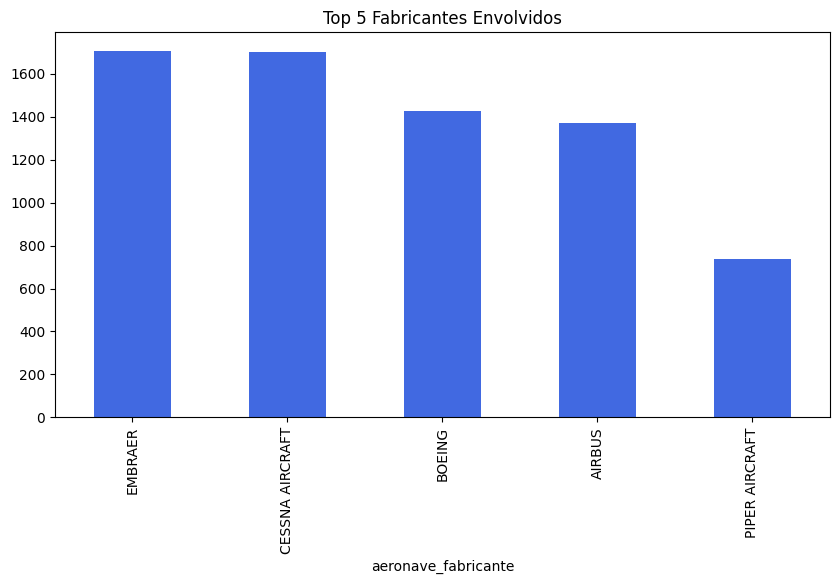

In [22]:
# Gerando um grafico de barras verticais com os nossos 5 maiores fabricantes
top_fabricantes.plot(
    kind="bar",
    title="Top 5 Fabricantes Envolvidos",
    color="royalblue",
    figsize=(10, 5)
)